# 1D Ornstein–Uhlenbeck process
##### Kostic et al. 2023 Example 3 Reproduction

$$X_{t+1} = e^{−1} X_{t}+\sqrt{1−e^{−2}}\, \epsilon_t$$

## Dynamical system setup

In [1]:
import numpy as np
import pandas as pd

from kooplearn._linalg import weighted_norm
from kooplearn.preprocessing import FeatureFlattener

x = np.linspace(-4, 4, 1025)[:, None]
flattener = FeatureFlattener()
x_flat = flattener.fit_transform(x)

# This is the exact density used in the paper for OU
density = np.exp(-0.5 * x_flat**2) / np.sqrt(2 * np.pi)


# ------------------------
# generate system dynamics
# ------------------------
def simulate_ou(n_steps, gamma, dt, random_state, x0=0.0):
    """AR(1) sampled from the exact OU transition at physical step size dt."""
    rng = np.random.default_rng(random_state)
    a = np.exp(-gamma * dt)
    b = np.sqrt(1.0 - a**2)
    x = np.empty(n_steps, dtype=float)
    x[0] = float(x0)
    for t in range(n_steps - 1):
        x[t + 1] = a * x[t] + b * rng.standard_normal()
    return pd.DataFrame({"x": x})


# ----------------------------------
# OU specific normalisation constant
# ----------------------------------
def ou_normalisation(functions, x, density):
    #    abs2 = np.abs(functions) ** 2
    #    norms = np.sqrt(np.trapezoid(abs2 * density[:, None], x[:, 0], axis=0))
    W = np.diag(density.reshape(-1))
    norms = weighted_norm(functions, W)
    norms = np.maximum(norms, 1e-12)
    functions = functions / norms
    return functions


# -----------------------------
# OU reference eigenfunctions
# -----------------------------
def compute_ou_eig(gamma, lag, num_components):
    n = np.arange(num_components)
    return np.exp(-n * gamma * lag)


## First, Fig. 2 but with OU

In [ ]:
from collections import defaultdict

import matplotlib.pyplot as plt
from tqdm import tqdm

from kooplearn.kernel import KernelRidge

# Parameters same as langevin version, where possible
n_train = 2000
subsample = 100
n_steps = n_train * subsample
n_trials = 10
dt = 1e-4
gamma = 1e-4


def fit_and_estimate(reduced_rank, x, density, random_state):
    # Substitute Langevin with OU

    data = simulate_ou(n_steps=n_steps, gamma=gamma, dt=dt, random_state=0, x0=0.0)
    data = data.iloc[::subsample][:n_train]

    # Model definition, same as fig 2 for now
    model = KernelRidge(
        n_components=5,
        reduced_rank=reduced_rank,
        gamma=12.5,
        kernel="rbf",
        alpha=1e-6,
        random_state=random_state,
    )

    # Fit and estimate eigenfunctions
    model.fit(data)  # fit transfer op model
    values, functions = model.eig(
        eval_right_on=x
    )  # (right) eigenvalue estimation, evaluate on array x
    sort_perm = np.flip(np.argsort(np.abs(values)))  # Order decreasingly
    values, functions = values[sort_perm], functions[:, sort_perm]
    functions = ou_normalisation(functions, x, density)
    return functions


# Run functions for both RRR (reduced rank) and kDMD (full rank) estimators

results = defaultdict(list)
for method, reduced_rank in zip(["Principal Components (kDMD)", "Reduced Rank"], [False, True]):
    for i in tqdm(range(n_trials)):
        results[method].append(fit_and_estimate(reduced_rank, x, density, i))

# Print results
fig, axs = plt.subplots(ncols=4, figsize=(9, 2))
for fun_id, ax in enumerate(axs):
    for method, functions in results.items():
        color = "tab:blue" if "Principal" in method else "tab:orange"
        ax.plot(x, functions[0][:, fun_id], color=color, label=method)
    ax.set_title(rf"Eigenfunction $\psi_{fun_id}$", fontsize=9)
    ax.set_xlim(-1, 1)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncols=2,
    frameon=False,
    bbox_to_anchor=(0.0, 1.05, 1.0, 0.102),
)
plt.tight_layout()
plt.show()


## Figure 1 reproduction
### Kernel family
$$k_{\Pi,\nu}(x,x')=\sum_{i\in\mathbb N}\mu_{\Pi(i)}^{2\nu} f_i(x)f_i(x')$$

#### Building callable Hermite kernel

In [2]:
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm

from kooplearn.kernel import KernelRidge

# ----------------------------------------------------------------------------------------------
# Hermite helpers / kernel family - in line with Kostic et al. Kernel construction in Example 3
# ----------------------------------------------------------------------------------------------


# -----------------------------
# FIX 1: bad/ugly share the SAME swap permutation.
# Only nu (the scaling exponent) differs between them.
# -----------------------------
def kernel_permutation(kind, r, M):
    pi = np.arange(M)
    if kind == "good":
        return pi
    if kind in ("bad", "ugly"):
        if 2 * r > M:
            raise ValueError(f"Need M >= 2*r, got M={M}, r={r}")
        pi2 = pi.copy()
        a = np.arange(r)
        b = np.arange(r, 2 * r)
        pi2[a] = b[::-1]
        pi2[b] = a[::-1]
        return pi2
    raise ValueError(kind)


def kernel_weights(kind, r, M):
    mu = np.exp(-np.arange(M))
    if kind == "good":
        nu = 1.0
    elif kind == "bad":
        nu = 1.0 / (r**2)
    elif kind == "ugly":
        nu = float(r**2)
    else:
        raise ValueError(kind)
    pi = kernel_permutation(kind, r, M)
    return mu[pi] ** (2.0 * nu)


def hermite_kernel(kind, r, M):
    w = kernel_weights(kind, r, M)
    cache = {}

    def get_features(x):
        key = np.asarray(x).ravel().tobytes()
        feats = cache.get(key)
        if feats is None:
            feats = hermite_features(x, M)[0]
            cache[key] = feats
        return feats

    def kernel(x, y):
        fx, fy = get_features(x), get_features(y)
        return float(np.sum(w * fx * fy))

    return kernel

def hermite_features(x, M):
    """Vectorized: x is (n,) or (n,1), returns (n, M) feature matrix."""
    x = np.asarray(x).reshape(-1)
    f = np.empty((x.shape[0], M))
    f[:, 0] = 1.0
    if M > 1:
        f[:, 1] = x
    for n in range(2, M):
        f[:, n] = (x * f[:, n - 1] - np.sqrt(n - 1) * f[:, n - 2]) / np.sqrt(n)
    return f

def weighted_features(x, kind, r, M):
    """Returns Phi_w such that k(x,x') = Phi_w(x) @ Phi_w(x').T"""
    w = kernel_weights(kind, r, M)          # (M,)
    Phi = hermite_features(x, M)        # (n, M)
    return Phi * np.sqrt(w)[None, :]        # weight each column once

def gram_matrix(X, Y, kind, r, M):
    """Vectorized full Gram matrix via matmul, no Python-level pairwise calls."""
    Phi_X = weighted_features(X, kind, r, M)
    Phi_Y = weighted_features(Y, kind, r, M)

    return Phi_X @ Phi_Y.T

def hermite_kernel_matrix(kind, r, M):
    w = kernel_weights(kind, r, M)
    def kernel(x, y):
        x = np.atleast_1d(x)
        y = np.atleast_1d(y)
        fx = hermite_features(x, M)[0]
        fy = hermite_features(y, M)[0]
        return float(np.sum(w * fx * fy))
    return kernel


In [3]:
# ---------------------------------------------
# Sign-align estimated functions to a reference
# ~ from kooplearn docs
# ---------------------------------------------


def standardize_sign(eigenfunction, reference, x):
    eigenfunction_cut = cut_functions_to_domain(eigenfunction, x)
    reference_cut = cut_functions_to_domain(reference, x)
    norm_p = np.linalg.norm(eigenfunction_cut + reference_cut)
    norm_m = np.linalg.norm(eigenfunction_cut - reference_cut)
    if norm_p <= norm_m:
        return -1.0 * eigenfunction
    else:
        return eigenfunction


def cut_functions_to_domain(functions, x, x_lims=(-1, 1)):
    mask = (x >= x_lims[0]) & (x <= x_lims[1])
    return functions[mask]


In [4]:
# -----------------------------
# FIX 2: T=53 truncation, n=20000 samples, gamma_reg=1e-4 (paper values)
# -----------------------------
import gc
import types
from scipy.sparse.linalg import ArpackNoConvergence

kernels = ["good", "bad", "ugly"]
methods = [("PCR", False), ("RRR", True)]

n_train = 5000
n_trials = 20 # paper uses 50
r = 3  # rank / number of leading eigenvalues shown
n_show = 3
M = 53  #  paper's "good" kernel truncates at T=53
gamma_reg = 1e-4  # was 1e-10 — paper's regularization gamma=1e-4

gamma_ou = 1.0
dt = 1.0
subsample = 1
lag = dt * subsample  # = 1.0, matching the paper's AR(1) definition exactly
true_eigs = compute_ou_eig(gamma_ou, lag, n_show)  # [1.0, 0.368, 0.135]

x = np.linspace(-4, 4, 1025)[:, None]

def make_model(kind, r, M, n_show, reduced_rank, gamma_reg, random_state):
    real_kernel = hermite_kernel_matrix(kind, r, M)   # correct scalar-safe callable

    model = KernelRidge(
        n_components=n_show,
        reduced_rank=reduced_rank,
        kernel=real_kernel,        # the actual kernel, not a placeholder
        alpha=gamma_reg,
        random_state=random_state,
        eigen_solver="arpack",
    )

    def _get_kernel(self, X, Y=None):
        if Y is None:
            Y = X
        return gram_matrix(X.ravel(), Y.ravel(), kind, r, M)

    model._get_kernel = types.MethodType(_get_kernel, model)
    return model

def fit_and_estimate_values(reduced_rank, x, random_state, kind, r, M, n_show):
    out = np.full(n_show, np.nan, dtype=float)

    data = simulate_ou(
        n_steps = n_train, gamma=gamma_ou, dt=dt, random_state=random_state, x0=0.0
    )[:n_train]

    model = make_model(kind, r, M, n_show, reduced_rank, gamma_reg, random_state=random_state
    )

    try:
        model.fit(data)
    except ArpackNoConvergence as e:
        print(f"Trial {trial} ARPACK failed to converge: {e}")
        return out 
    values, _ = model.eig(eval_right_on=x)
    values = np.real_if_close(np.asarray(values))
    if values.ndim == 0:
        values = np.array([values])

    real_mask = np.abs(np.imag(values)) < gamma_reg
    values = np.real(values[real_mask])
    values = values[np.isfinite(values)]
    values = values[values <= 1.0 + gamma_reg]
    values = np.sort(values)[::-1]

    k = min(n_show, values.size)
    out[:k] = values[:k]
    # break the cycle created by the monkey-patched bound method
    if model is not None:
        if hasattr(model, "_get_kernel"):
            del model._get_kernel
        for attr in ("kernel_X_", "kernel_Y_", "kernel_YX_"):
            if hasattr(model, attr):
                delattr(model, attr)
        del model
        gc.collect()
    return out



results = defaultdict(list)

for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            vals = fit_and_estimate_values(reduced_rank, x, trial, kind, r, M, n_show)
            results[(kind, method)].append(vals)

            # explicitly break the reference cycle from monkey-patching
            del vals
            gc.collect()


ugly-RRR:   0%|          | 0/20 [00:00<?, ?it/s]/home/scj/.local/lib/python3.14/site-packages/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 2 dimensions of the 3 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 1.393e-15.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
ugly-RRR:   5%|▌         | 1/20 [00:11<03:29, 11.05s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 2 dimensions of the 3 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 7.587e-15.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
ugly-RRR:  10%|█         | 2/20 [00:22<03:18, 11.06s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 2 dimensions of the 3 requested due to numerical instability. Consider decreasing k_max. The largest disca

In [9]:
from scipy.stats import gaussian_kde

def combined_density(vals_matrix, xgrid):
    """Average per-mode KDEs instead of pooling raw values into one KDE."""
    log_xgrid = np.log(xgrid)
    total_density = np.zeros_like(xgrid)
    n_modes_used = 0

    for col in range(vals_matrix.shape[1]):
        col_vals = vals_matrix[:, col]
        col_vals = col_vals[np.isfinite(col_vals) & (col_vals > 0)]
        if col_vals.size < 2:
            continue

        log_vals = np.log(col_vals)
        std = np.std(log_vals)

        if std < 1e-4:
            # near-delta cluster (e.g. mode 0 in "good" kernel): fixed small bandwidth
            bw = 0.02
            kde_vals = np.exp(-0.5 * ((log_xgrid - np.mean(log_vals)) / bw) ** 2) / (bw * np.sqrt(2 * np.pi))
        else:
            kde = gaussian_kde(log_vals, bw_method=0.15)
            kde_vals = kde(log_xgrid)

        total_density += kde_vals
        n_modes_used += 1

    if n_modes_used > 0:
        total_density /= n_modes_used
    return total_density

In [15]:
def pooled_log_kde(vals_matrix, xgrid, boundary=1.0, bw_method=0.15):
    vals = vals_matrix.ravel()
    vals = vals[np.isfinite(vals) & (vals > 0) & (vals <= boundary)]
    if vals.size < 2:
        return np.zeros_like(xgrid)

    log_vals = np.log(vals)
    log_boundary = np.log(boundary)
    reflected = 2 * log_boundary - log_vals
    combined = np.concatenate([log_vals, reflected])

    kde = gaussian_kde(combined, bw_method=bw_method)  # fixed bandwidth, not "scott"
    log_xgrid = np.log(xgrid)
    density = kde(log_xgrid) * 2
    density[xgrid > boundary] = 0.0
    return density

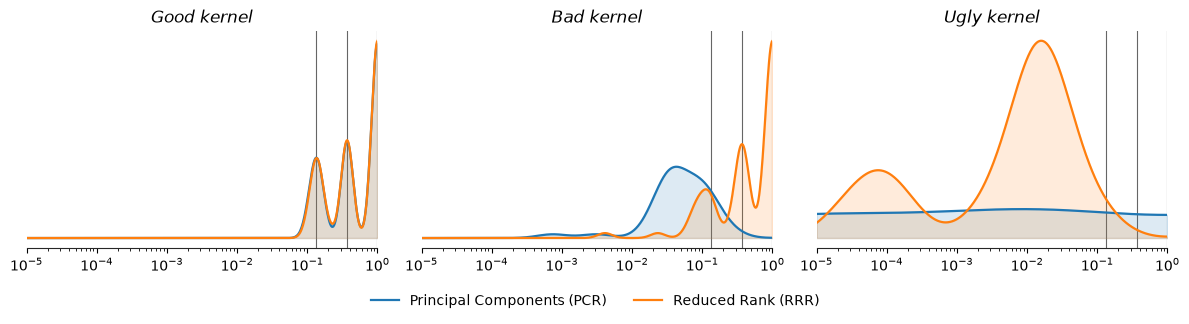

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "axes.edgecolor": "0.15",
    "axes.linewidth": 0.8, "axes.titlesize": 12,
})

log_lo, log_hi = -5, 0
xgrid = np.logspace(log_lo, log_hi, 500)
true_eigs = [1.0, 0.368, 0.135]

fig, axs = plt.subplots(ncols=3, figsize=(12, 3.2), sharey=False)

for col, kind in enumerate(kernels):
    ax = axs[col]
    for method, color in [("PCR", "tab:blue"), ("RRR", "tab:orange")]:
        arr = np.asarray(results[(kind, method)], dtype=float)
        density = pooled_log_kde(arr, xgrid)
        ax.plot(xgrid, density, color=color, lw=1.6,
                label="Reduced Rank (RRR)" if method == "RRR" else "Principal Components (PCR)")
        ax.fill_between(xgrid, density, color=color, alpha=0.15)

    for ev in true_eigs:
        ax.axvline(ev, color="0.4", lw=0.8, zorder=0)

    ax.set_xscale("log")
    ax.set_xlim(10**log_lo, 10**log_hi)
    ax.set_title(f"{kind.capitalize()} kernel", style="italic", fontsize=12)
    ax.set_yticks([])
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("fig1_v9.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
for kind in kernels:
    for method in ["PCR", "RRR"]:
        arr = np.asarray(results[(kind, method)], dtype=float)
        density = combined_density(arr, xgrid)
        print(kind, method, "max density:", density.max(), "at x =", xgrid[np.argmax(density)])

good PCR max density: 8.803485699976136 at x = 0.37079876291681724
good RRR max density: 8.04424526523251 at x = 0.37079876291681724
bad PCR max density: 0.7791998079066244 at x = 0.0344408727597382
bad RRR max density: 8.844893078313978 at x = 0.37079876291681724
ugly PCR max density: 0.03915892338795426 at x = 0.015717837177731626
ugly RRR max density: 0.5152392068020077 at x = 0.01608469483265355


In [8]:

for key in [("good", "PCR"), ("good", "RRR"), ("bad", "PCR")]:
    arr = np.asarray(results[key], dtype=float)  # shape: (n_trials, n_show)
    print(f"\n=== {key} ===")
    print("Raw array (trials x modes):")
    print(arr)

    flat = arr.ravel()
    n_total = flat.size
    n_nan = np.sum(np.isnan(flat))
    n_valid = n_total - n_nan
    print(f"Total slots: {n_total}, NaN: {n_nan}, valid: {n_valid}")

    valid_vals = flat[np.isfinite(flat)]
    print("Valid values sorted:", np.sort(valid_vals))

    # check how many land in each true-eigenvalue neighborhood
    true_eigs = np.array([1.0, 0.368, 0.135])
    for te in true_eigs:
        near = valid_vals[np.abs(valid_vals - te) < 0.05]
        print(f"  values within 0.05 of true eig {te:.3f}: {len(near)} -> {near}")

    # check how many are getting clipped near the upper bound
    near_one = valid_vals[valid_vals > 0.999]
    print(f"  values > 0.999 (potential boundary clipping): {len(near_one)}")

    # check per-mode-column breakdown (since arr is sorted descending per trial)
    for col in range(arr.shape[1]):
        col_vals = arr[:, col]
        col_valid = col_vals[np.isfinite(col_vals)]
        print(f"  Mode column {col}: n_valid={len(col_valid)}, "
              f"mean={np.nanmean(col_vals):.4f}, "
              f"min={np.nanmin(col_valid) if len(col_valid) else np.nan:.4f}, "
              f"max={np.nanmax(col_valid) if len(col_valid) else np.nan:.4f}")


=== ('good', 'PCR') ===
Raw array (trials x modes):
[[0.99990001 0.36581207 0.10388359]
 [0.99990001 0.36204217 0.13919751]
 [0.99990001 0.34939049 0.12770066]
 [0.99990001 0.37658523 0.14454738]
 [0.9999     0.36071936 0.17108704]
 [0.99990002 0.38275899 0.10197733]
 [0.99990001 0.36980109 0.14355211]
 [0.99990001 0.37939977 0.12439582]
 [0.99990001 0.34667208 0.11706331]
 [0.99990001 0.37208183 0.15210156]
 [0.99990001 0.36085692 0.13409992]
 [0.99990001 0.379253   0.1241304 ]
 [0.99990001 0.37269832 0.13074228]
 [0.99990001 0.3803564  0.16477743]
 [0.99990001 0.36172544 0.11904844]
 [0.99990001 0.37469992 0.14817125]
 [0.99990001 0.36932377 0.12651714]
 [0.99990001 0.37121043 0.15234319]
 [0.99990001 0.37087374 0.14444443]
 [0.9999     0.37190852 0.12693979]]
Total slots: 60, NaN: 0, valid: 60
Valid values sorted: [0.10197733 0.10388359 0.11706331 0.11904844 0.1241304  0.12439582
 0.12651714 0.12693979 0.12770066 0.13074228 0.13409992 0.13919751
 0.14355211 0.14444443 0.14454738 0.